# Drug Review Sentiment Analysis: BioBERT vs. ClinicalBERT vs. Baselines

## Research Question
*Can domain-specific language models fine-tuned on patient drug reviews meaningfully outperform traditional lexicon-based or classical ML approaches for 5-class sentiment classification?* 

*Furthermore, does pre-training on clinical doctor's notes (ClinicalBERT) provide a measurable advantage over pre-training on academic biomedical literature (BioBERT) when analyzing informal patient language?*

---

## Experimental Overview
This notebook implements a controlled comparative study across **seven sentiment analysis approaches** on the UCI Drug Review dataset:

| # | Approach | Type |
|---|----------|------|
| 1 | **VADER** | Rule-based lexicon |
| 2 | **TextBlob** | Lexicon + pattern analysis |
| 3 | **TF-IDF + Multinomial Naive Bayes** | Classical ML |
| 4 | **BioBERT (Base / No Fine-Tuning)** | Pre-trained transformer, no fine-tuning |
| 5 | **BioBERT (Fine-Tuned)** | Domain-adapted transformer |
| 6 | **ClinicalBERT (Base / No Fine-Tuning)** | Transformer pre-trained on MIMIC-III clinical notes |
| 7 | **ClinicalBERT (Fine-Tuned)** | Domain-adapted transformer (Clinical) |

The central hypothesis is that domain-specific transformer models will drastically outperform the baselines, and that **ClinicalBERT** may slightly outperform **BioBERT** because its pre-training data (messy, informal doctor's notes) is linguistically closer to patient forum posts than BioBERT's pre-training data (highly formal academic PubMed papers).

All models are evaluated on the **same held-out test split** using **Weighted F1-Score** and **Accuracy**.


---
## 1. Environment Setup

We install and import all required libraries. The `transformers` and `datasets` libraries
from HuggingFace are the backbone of the BioBERT pipeline. `vaderSentiment` and `textblob`
provide the lexicon baselines. `scikit-learn` handles classical ML and all evaluation
metrics. `seaborn` and `matplotlib` are used for result visualizations.


In [1]:
# Downgrade PyTorch to a CUDA 11.8 build to retain support for the Tesla P100 GPU (Pascal architecture)
!pip install torch==2.7.1+cu118 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet
!pip install transformers datasets accelerate vaderSentiment textblob scikit-learn --quiet

import os
import gc
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 70.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 52.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 102.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 33.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 12.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

---
## 2. Dataset Loading and Initial Exploration

The dataset originates from the [UCI ML Drug Review Dataset](https://archive.ics.uci.edu/ml/datasets/Drug+Review+Dataset+%28Drugs.com%29)
and was made available for the KUC Hackathon Winter 2018. It contains **patient
reviews** scraped from Drugs.com, with the following key columns:

| Column | Description |
|--------|-------------|
| `drugName` | Name of the drug being reviewed |
| `condition` | Medical condition the drug was prescribed for |
| `review` | Free-text patient review (**our input feature**) |
| `rating` | 1–10 user satisfaction rating (**our proxy label**) |
| `date` | Date the review was submitted |
| `usefulCount` | Number of users who found the review useful |

We merge the provided train and test CSVs into a single DataFrame so we can apply
our own stratified, balanced split. This prevents the original split from introducing
any distribution bias into our controlled experiment.


In [2]:
TRAIN_PATH = "/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv"
TEST_PATH  = "/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTest_raw.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

df_train["rating"] = df_train["rating"].astype(int)
df_test["rating"]  = df_test["rating"].astype(int)

df = pd.concat([df_train, df_test], ignore_index=True)
df.drop_duplicates(subset=["review"], inplace=True)
df.dropna(subset=["review", "rating"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Total reviews after deduplication: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")


Total reviews after deduplication: 128,478
Columns: ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']


In [3]:
display(df.head(5))


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


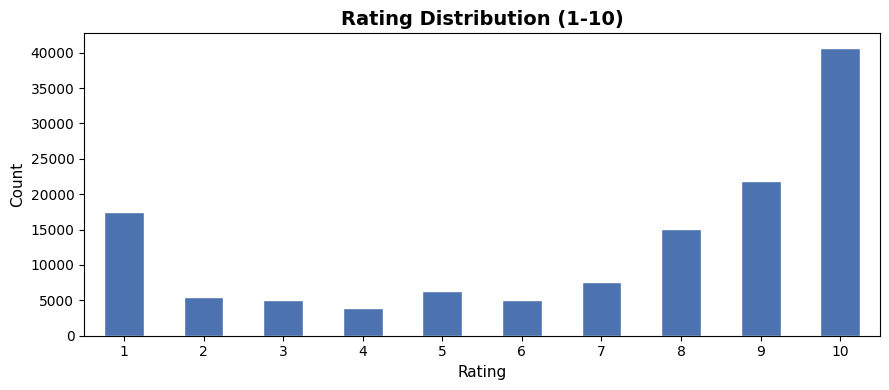


Rating value counts:
rating
1     17425
2      5415
3      5083
4      3903
5      6382
6      5046
7      7563
8     15068
9     21903
10    40690
Name: count, dtype: int64


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#4C72B0", edgecolor="white"
)
ax.set_title("Rating Distribution (1-10)", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("\nRating value counts:")
print(df["rating"].value_counts().sort_index())


---
## 3. Label Engineering: Rating → Sentiment Class

The 10-point rating scale is a *proxy* for sentiment. We bin it into **5 ordinal
sentiment classes**:

| Rating Range | Sentiment Class | Numeric Label |
|:---:|:---|:---:|
| 1 – 2 | Very Negative | 0 |
| 3 – 4 | Negative | 1 |
| 5 – 6 | Neutral | 2 |
| 7 – 8 | Positive | 3 |
| 9 – 10 | Very Positive | 4 |

Five classes better reflect the nuanced spectrum of patient sentiment and create a more
challenging, realistic benchmark than a 2- or 3-class schema.

> **Limitation Note**: This is a deliberate but subjective mapping. A rating of 5 or 6
> may reflect mild dissatisfaction, neutral indifference, or moderate satisfaction
> depending on the individual patient's baseline expectations.


In [5]:
LABEL2ID = {
    "very negative": 0,
    "negative":      1,
    "neutral":       2,
    "positive":      3,
    "very positive": 4,
}
ID2LABEL      = {v: k for k, v in LABEL2ID.items()}
RATING_LABELS = ["very negative", "negative", "neutral", "positive", "very positive"]
RATING_BINS   = [0, 2, 4, 6, 8, 10]

df["sentiment"] = pd.cut(
    df["rating"],
    bins=RATING_BINS,
    labels=RATING_LABELS,
    right=True,
).astype(str)

df["sentiment_label"] = df["sentiment"].map(LABEL2ID)

print("Sentiment class distribution:")
print(df["sentiment"].value_counts())


Sentiment class distribution:
sentiment
very positive    62593
very negative    22840
positive         22631
neutral          11428
negative          8986
Name: count, dtype: int64


---
## 4. Dataset Balancing and Splitting

The raw dataset is heavily skewed toward positive ratings — most patients who write a
review do so because they experienced a benefit. Training on this imbalance causes
classifiers to over-predict positive classes, inflating accuracy while suppressing
recall on minority classes.

**Strategy**: We sample exactly **7,000 reviews per class** (35,000 total) to create a
perfectly balanced training corpus. All remaining reviews (~93,000+) form a large hold-out evaluation set. This design ensures:
1. All models are trained on identical, class-balanced data — enabling fair comparison.
2. Evaluation on the naturalistic hold-out set reflects real-world generalization.


In [6]:
TARGET_SIZE    = 7000
balanced_parts = []
extra_parts    = []

for label in RATING_LABELS:
    class_df = df[df["sentiment"] == label].copy()
    if len(class_df) < TARGET_SIZE:
        raise ValueError(
            f"Not enough samples for class '{label}': {len(class_df)} < {TARGET_SIZE}"
        )
    sampled  = class_df.sample(n=TARGET_SIZE, random_state=42)
    leftover = class_df.drop(sampled.index)
    balanced_parts.append(sampled)
    extra_parts.append(leftover)

balanced_df = pd.concat(balanced_parts, ignore_index=True)
extra_df    = pd.concat(extra_parts,    ignore_index=True)

print(f"Balanced dataset (training pool) : {balanced_df.shape}")
print(f"Extra dataset (evaluation pool)  : {extra_df.shape}")
print()
print("Balanced class distribution:")
print(balanced_df["sentiment"].value_counts())


Balanced dataset (training pool) : (35000, 9)
Extra dataset (evaluation pool)  : (93478, 9)

Balanced class distribution:
sentiment
very negative    7000
negative         7000
neutral          7000
positive         7000
very positive    7000
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced_df[["review", "sentiment", "sentiment_label"]],
    test_size=0.30,
    stratify=balanced_df["sentiment_label"],
    random_state=34,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Training set   : {train_df.shape}")
print(f"Validation set : {val_df.shape}")
print(f"Evaluation set : {extra_df.shape}")
print()
print("Training class distribution:")
print(train_df["sentiment"].value_counts())


Training set   : (24500, 3)
Validation set : (10500, 3)
Evaluation set : (93478, 9)

Training class distribution:
sentiment
positive         4900
negative         4900
very positive    4900
very negative    4900
neutral          4900
Name: count, dtype: int64


---
## 5. Baseline Models

We establish three non-transformer baselines. The thresholding strategy below maps
continuous polarity scores onto our 5-class schema consistently across VADER and TextBlob:

| Compound / Polarity Score | Mapped Class |
|:-:|:-|
| ≥ 0.60 | very positive |
| ≥ 0.10 | positive |
| > −0.10 | neutral |
| > −0.60 | negative |
| ≤ −0.60 | very negative |

### 5.1 VADER (Valence Aware Dictionary and sEntiment Reasoner)
VADER uses a hand-crafted, valence-rated lexicon with special rules for capitalization,
punctuation, and degree modifiers. It was designed for short-form social media text.

### 5.2 TextBlob
TextBlob's `PatternAnalyzer` computes a polarity score via adjective patterns. It is
generally weaker than VADER on medical text due to its narrower coverage.

### 5.3 TF-IDF + Multinomial Naive Bayes
A bag-of-words model trained on TF-IDF features (top 10,000 unigrams/bigrams) from the
training set. Unlike lexicon methods, it *learns* word-class associations from data,
making it significantly more competitive.

> All three baselines are configured or trained on `train_df` for a fair comparison.


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# VADER
sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.60:  return "very positive"
    if score >= 0.10:  return "positive"
    if score > -0.10:  return "neutral"
    if score > -0.60:  return "negative"
    return "very negative"

# TextBlob
def textblob_predict(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score >= 0.60:  return "very positive"
    if score >= 0.10:  return "positive"
    if score > -0.10:  return "neutral"
    if score > -0.60:  return "negative"
    return "very negative"

# TF-IDF + Multinomial Naive Bayes
mnb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english",
        sublinear_tf=True,
    )),
    ("clf", MultinomialNB(alpha=0.1)),
])
mnb_pipeline.fit(train_df["review"], train_df["sentiment"])

print("Baseline models ready.")
print(f"  VADER      : rule-based, no training required")
print(f"  TextBlob   : rule-based, no training required")
print(f"  Naive Bayes: trained on {len(train_df):,} samples")


Baseline models ready.
  VADER      : rule-based, no training required
  TextBlob   : rule-based, no training required
  Naive Bayes: trained on 24,500 samples


In [9]:
print("Running VADER predictions on validation set...")
val_df["vader_pred"] = val_df["review"].apply(vader_predict)

print("Running TextBlob predictions on validation set...")
val_df["textblob_pred"] = val_df["review"].apply(textblob_predict)

print("Running Naive Bayes predictions on validation set...")
val_df["mnb_pred"] = mnb_pipeline.predict(val_df["review"])

print("Done.")


Running VADER predictions on validation set...
Running TextBlob predictions on validation set...
Running Naive Bayes predictions on validation set...
Done.


In [10]:
def evaluate(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    sep = "─" * 55
    print(f"\n{sep}")
    print(f"  {model_name}")
    print(f"{sep}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Weighted F1 : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=RATING_LABELS))
    return {"model": model_name, "accuracy": acc, "weighted_f1": f1}

baseline_results = []
baseline_results.append(evaluate(val_df["sentiment"], val_df["vader_pred"],    "VADER"))
baseline_results.append(evaluate(val_df["sentiment"], val_df["textblob_pred"], "TextBlob"))
baseline_results.append(evaluate(val_df["sentiment"], val_df["mnb_pred"],      "TF-IDF + Naive Bayes"))



───────────────────────────────────────────────────────
  VADER
───────────────────────────────────────────────────────
  Accuracy    : 0.2790
  Weighted F1 : 0.2553

               precision    recall  f1-score   support

very negative       0.22      0.20      0.21      2100
     negative       0.22      0.07      0.11      2100
      neutral       0.23      0.19      0.21      2100
     positive       0.30      0.54      0.38      2100
very positive       0.34      0.40      0.37      2100

     accuracy                           0.28     10500
    macro avg       0.26      0.28      0.26     10500
 weighted avg       0.26      0.28      0.26     10500


───────────────────────────────────────────────────────
  TextBlob
───────────────────────────────────────────────────────
  Accuracy    : 0.2487
  Weighted F1 : 0.2018

               precision    recall  f1-score   support

very negative       0.25      0.26      0.26      2100
     negative       0.22      0.50      0.31      21

---
## 6. Base BioBERT (No Fine-Tuning) — Baseline

Before fine-tuning, we benchmark the *pre-trained* BioBERT model directly. This is a
crucial baseline: it isolates the contribution of **fine-tuning** from the model's
inherent domain vocabulary advantage.

We load BioBERT with a randomly initialized 5-class classification head and run
inference on the validation set without any task-specific training. The model is
expected to perform near chance (~20%) or slightly above due to the structure of
its embedding space.

> **Why this matters**: If fine-tuned BioBERT scores significantly higher than base
> BioBERT, the gain is attributable to *learning the task from data*, not just from
> using a biomedical vocabulary.


In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset as TorchDataset

BIOBERT_HUB_ID = "dmis-lab/biobert-base-cased-v1.2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(BIOBERT_HUB_ID)
print(f"Tokenizer loaded from: {BIOBERT_HUB_ID}")


Using device: cuda


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded from: dmis-lab/biobert-base-cased-v1.2


In [12]:
class ReviewDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        # Store as lists, but DO NOT tokenize yet to save memory
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenize lazily on-the-fly when the DataLoader requests a batch
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        
        # Squeeze removes the batch dimension added by return_tensors="pt"
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def batch_predict(model, dataset, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            kwargs = {"input_ids": ids, "attention_mask": mask}
            
            if "token_type_ids" in batch:
                kwargs["token_type_ids"] = batch["token_type_ids"].to(DEVICE)
                
            outputs = model(**kwargs)
            preds   = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            
    return np.array(all_preds)


In [13]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_HUB_ID,
    num_labels=5,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
base_model.to(DEVICE)

val_labels_int = val_df["sentiment_label"].astype(int).tolist()
val_dataset    = ReviewDataset(val_df["review"], val_labels_int, tokenizer, max_length=256)

print("Running base BioBERT (no fine-tuning) on validation set...")
base_preds_int = batch_predict(base_model, val_dataset)
base_preds_str = [ID2LABEL[i] for i in base_preds_int]

base_result = evaluate(val_df["sentiment"], base_preds_str, "BioBERT (Base, No Fine-Tuning)")
baseline_results.append(base_result)

del base_model
torch.cuda.empty_cache()
print("GPU memory cleared.")


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Running base BioBERT (no fine-tuning) on validation set...

───────────────────────────────────────────────────────
  BioBERT (Base, No Fine-Tuning)
───────────────────────────────────────────────────────
  Accuracy    : 0.1907
  Weighted F1 : 0.1218

               precision    recall  f1-score   support

very negative       0.19      0.69      0.30      2100
     negative       0.00      0.00      0.00      2100
      neutral       0.00      0.00      0.00      2100
     positive       0.21      0.13      0.16      2100
very positive       0.16      0.13      0.14      2100

     accuracy                           0.19     10500
    macro avg       0.11      0.19      0.12     10500
 weighted avg       0.11      0.19      0.12     10500

GPU memory cleared.


---
## 7. BioBERT Fine-Tuning

This is the core experiment. We fine-tune BioBERT for 5-class sequence classification
on our 24,500-sample training set using the HuggingFace `Trainer` API.

### Hyperparameter Rationale

| Hyperparameter | Value | Rationale |
|:---|:---|:---|
| `num_train_epochs` | 3 | Sufficient for convergence; early stopping prevents overfitting |
| `per_device_train_batch_size` | 8 | Fits P100/T4 VRAM with 256-token sequences |
| `gradient_accumulation_steps` | 4 | Effective batch size of 32 |
| `learning_rate` | 2e-5 | Standard BERT fine-tuning rate; avoids catastrophic forgetting |
| `warmup_ratio` | 0.06 | Warm up over first 6% of steps for stable gradient flow |
| `weight_decay` | 0.01 | L2 regularization on non-bias parameters |
| `max_length` | 256 | ~95% of reviews fit; halves memory cost vs 512 |
| `hidden_dropout_prob` | 0.2 | Slightly higher than default 0.1 to regularize the head |
| `metric_for_best_model` | `f1` | Optimize Weighted F1, not accuracy |

### Early Stopping
Training halts if Weighted F1 does not improve by ≥ 0.005 across 3 consecutive
evaluations (checked every 500 steps). The best checkpoint is automatically restored.


In [14]:
from datasets import Dataset as HFDataset
from transformers import (
    TrainingArguments, Trainer,
    EarlyStoppingCallback, DataCollatorWithPadding,
)

MAX_LENGTH     = 256
FINETUNED_DIR  = "/kaggle/working/biobert_finetuned"
BEST_MODEL_DIR = "/kaggle/working/biobert_best"

hf_train = HFDataset.from_dict({
    "text":   train_df["review"].tolist(),
    "labels": train_df["sentiment_label"].astype(int).tolist(),
})
hf_val = HFDataset.from_dict({
    "text":   val_df["review"].tolist(),
    "labels": val_df["sentiment_label"].astype(int).tolist(),
})

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

hf_train_tok = hf_train.map(tokenize_fn, batched=True, remove_columns=["text"])
hf_val_tok   = hf_val.map(tokenize_fn,   batched=True, remove_columns=["text"])

print(f"Training samples  : {len(hf_train_tok):,}")
print(f"Validation samples: {len(hf_val_tok):,}")
print(f"Features          : {hf_train_tok.column_names}")


Map:   0%|          | 0/24500 [00:00<?, ? examples/s]

Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Training samples  : 24,500
Validation samples: 10,500
Features          : ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted"),
    }


ft_model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_HUB_ID,
    num_labels=5,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2,
    ignore_mismatched_sizes=True,
)

training_args = TrainingArguments(
    output_dir=FINETUNED_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    warmup_ratio=0.06,
    weight_decay=0.01,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_val_tok,
    # tokenizer=tokenizer,  <--- REMOVED to fix the newer library error
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.005,
        )
    ],
)

print("Starting fine-tuning...")
train_result = trainer.train()
print("Fine-tuning complete.")
print(f"  Runtime       : {train_result.metrics['train_runtime']:.0f} seconds")
print(f"  Training loss : {train_result.training_loss:.4f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Starting fine-tuning...


Step,Training Loss,Validation Loss,Accuracy,F1
500,5.156785,1.185360,0.482952,0.472473
1000,4.494103,1.156727,0.498476,0.485764
1500,4.437881,1.121934,0.517905,0.512433
2000,4.090061,1.142898,0.516000,0.512427


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Fine-tuning complete.
  Runtime       : 1755 seconds
  Training loss : 4.6809


In [17]:
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f"Best model saved to: {BEST_MODEL_DIR}")
print(f"Files: {os.listdir(BEST_MODEL_DIR)}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /kaggle/working/biobert_best
Files: ['config.json', 'training_args.bin', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


---
## 8. Fine-Tuned BioBERT Evaluation

We evaluate the fine-tuned model on:
1. The **validation set** (same 30% balanced split used during training) — measures
   in-distribution performance.
2. The large **hold-out set** (~180K naturally-distributed reviews) — measures
   real-world generalization where class imbalance is present.

We reload the model from disk to ensure we are running the *saved best checkpoint*,
not the in-memory trainer state.


In [18]:
ft_model_eval = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR)
ft_model_eval.to(DEVICE)

val_dataset_ft = ReviewDataset(val_df["review"], val_labels_int, tokenizer, max_length=MAX_LENGTH)

print("Running fine-tuned BioBERT on validation set...")
ft_preds_int = batch_predict(ft_model_eval, val_dataset_ft, batch_size=32)
ft_preds_str = [ID2LABEL[i] for i in ft_preds_int]

ft_val_result = evaluate(val_df["sentiment"], ft_preds_str, "BioBERT (Fine-Tuned) — Validation Set")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running fine-tuned BioBERT on validation set...

───────────────────────────────────────────────────────
  BioBERT (Fine-Tuned) — Validation Set
───────────────────────────────────────────────────────
  Accuracy    : 0.5181
  Weighted F1 : 0.5126

               precision    recall  f1-score   support

very negative       0.41      0.43      0.42      2100
     negative       0.40      0.31      0.35      2100
      neutral       0.47      0.49      0.48      2100
     positive       0.61      0.69      0.65      2100
very positive       0.66      0.67      0.67      2100

     accuracy                           0.52     10500
    macro avg       0.51      0.52      0.51     10500
 weighted avg       0.51      0.52      0.51     10500



In [19]:
extra_labels_int = extra_df["sentiment_label"].astype(int).tolist()
extra_dataset    = ReviewDataset(extra_df["review"], extra_labels_int, tokenizer, max_length=MAX_LENGTH)

print(f"Running fine-tuned BioBERT on {len(extra_df):,} hold-out reviews...")
print("This will take several minutes on GPU...")
extra_preds_int = batch_predict(ft_model_eval, extra_dataset, batch_size=64)
extra_preds_str = [ID2LABEL[i] for i in extra_preds_int]

extra_df["biobert_ft_pred"] = extra_preds_str

ft_extra_result = evaluate(
    extra_df["sentiment"],
    extra_df["biobert_ft_pred"],
    "BioBERT (Fine-Tuned)",
)


Running fine-tuned BioBERT on 93,478 hold-out reviews...
This will take several minutes on GPU...

───────────────────────────────────────────────────────
  BioBERT (Fine-Tuned) — Hold-Out Set
───────────────────────────────────────────────────────
  Accuracy    : 0.6139
  Weighted F1 : 0.6565

               precision    recall  f1-score   support

very negative       0.10      0.41      0.17      1986
     negative       0.17      0.30      0.22      4428
      neutral       0.32      0.46      0.38     15631
     positive       0.80      0.68      0.73     15840
very positive       0.89      0.67      0.76     55593

     accuracy                           0.61     93478
    macro avg       0.46      0.50      0.45     93478
 weighted avg       0.73      0.61      0.66     93478



---
## 9. ClinicalBERT: Base (No Fine-Tuning)
We now introduce **Bio_ClinicalBERT**. While BioBERT was pre-trained on formal academic papers (PubMed), ClinicalBERT was initialized from BioBERT and trained further on the MIMIC-III database (electronic health records and clinical doctor's notes). Doctor's notes are messier, containing typos and informal shorthand. We hypothesize this makes ClinicalBERT's internal representations better suited for analyzing messy, patient-written forum reviews.


In [20]:
# Clear BioBERT from GPU memory
try:
    del trainer, ft_model, ft_model_eval
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

CLINBERT_ID = "emilyalsentzer/Bio_ClinicalBERT"
clin_tokenizer = AutoTokenizer.from_pretrained(CLINBERT_ID)

clin_val_dataset = ReviewDataset(val_df["review"], val_labels_int, clin_tokenizer, max_length=MAX_LENGTH)
clin_extra_dataset = ReviewDataset(extra_df["review"], extra_labels_int, clin_tokenizer, max_length=MAX_LENGTH)

print("Loading Base ClinicalBERT...")
clin_base = AutoModelForSequenceClassification.from_pretrained(
    CLINBERT_ID, num_labels=5, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True
).to(DEVICE)

print("Running base ClinicalBERT on validation set...")
clin_base_preds = batch_predict(clin_base, clin_val_dataset)
clin_base_result = evaluate(val_df["sentiment"], [ID2LABEL[i] for i in clin_base_preds], "ClinicalBERT (Base)")
baseline_results.append(clin_base_result)

del clin_base
gc.collect()
torch.cuda.empty_cache()


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loading Base ClinicalBERT...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Running base ClinicalBERT on validation set...


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]


───────────────────────────────────────────────────────
  ClinicalBERT (Base)
───────────────────────────────────────────────────────
  Accuracy    : 0.2200
  Weighted F1 : 0.1417

               precision    recall  f1-score   support

very negative       0.21      0.52      0.30      2100
     negative       0.00      0.00      0.00      2100
      neutral       0.00      0.00      0.00      2100
     positive       0.24      0.06      0.09      2100
very positive       0.22      0.52      0.31      2100

     accuracy                           0.22     10500
    macro avg       0.14      0.22      0.14     10500
 weighted avg       0.14      0.22      0.14     10500



---
## 10. ClinicalBERT Fine-Tuning
We now fine-tune ClinicalBERT using the exact same hyperparameters and 24,500-sample training dataset. If ClinicalBERT achieves a higher Weighted F1 score, it suggests that aligning the *style* of the pre-training corpus (informal clinical notes) with the downstream task (informal patient reviews) yields a tangible performance benefit.


In [21]:
print("Tokenizing training data for ClinicalBERT...")
def clin_tokenize_fn(batch):
    return clin_tokenizer(batch["text"], padding=False, truncation=True, max_length=MAX_LENGTH)

clin_hf_train_tok = hf_train.map(clin_tokenize_fn, batched=True, remove_columns=["text"])
clin_hf_val_tok   = hf_val.map(clin_tokenize_fn, batched=True, remove_columns=["text"])

CLIN_FINETUNED_DIR = "/kaggle/working/clinbert_finetuned"
CLIN_BEST_MODEL_DIR = "/kaggle/working/clinbert_best"

clin_ft_model = AutoModelForSequenceClassification.from_pretrained(
    CLINBERT_ID, num_labels=5, id2label=ID2LABEL, label2id=LABEL2ID, 
    hidden_dropout_prob=0.2, attention_probs_dropout_prob=0.2, ignore_mismatched_sizes=True
)

clin_trainer = Trainer(
    model=clin_ft_model,
    args=training_args, 
    train_dataset=clin_hf_train_tok,
    eval_dataset=clin_hf_val_tok,
    data_collator=DataCollatorWithPadding(clin_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.005)],
)

print("Starting ClinicalBERT fine-tuning...")
clin_trainer.train()
clin_trainer.save_model(CLIN_BEST_MODEL_DIR)


Tokenizing training data for ClinicalBERT...


Map:   0%|          | 0/24500 [00:00<?, ? examples/s]

Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
clin_ft_eval = AutoModelForSequenceClassification.from_pretrained(CLIN_BEST_MODEL_DIR).to(DEVICE)

print(f"Running fine-tuned ClinicalBERT on hold-out reviews...")
clin_extra_preds_int = batch_predict(clin_ft_eval, clin_extra_dataset, batch_size=64)

extra_df["clinbert_ft_pred"] = [ID2LABEL[i] for i in clin_extra_preds_int]
clin_ft_extra_result = evaluate(
    extra_df["sentiment"], extra_df["clinbert_ft_pred"], "ClinicalBERT (Fine-Tuned)"
)


del clin_ft_eval
gc.collect()
torch.cuda.empty_cache()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running fine-tuned ClinicalBERT on hold-out reviews...

───────────────────────────────────────────────────────
  ClinicalBERT (Fine-Tuned)
───────────────────────────────────────────────────────
  Accuracy    : 0.5915
  Weighted F1 : 0.6370

               precision    recall  f1-score   support

very negative       0.10      0.36      0.16      1986
     negative       0.15      0.37      0.22      4428
      neutral       0.31      0.43      0.36     15631
     positive       0.75      0.67      0.71     15840
very positive       0.89      0.64      0.74     55593

     accuracy                           0.59     93478
    macro avg       0.44      0.49      0.44     93478
 weighted avg       0.72      0.59      0.64     93478



---
## 11. Baseline Predictions on the Hold-Out Set

For a fully apples-to-apples comparison on the real-world distribution, we run all
baseline models on the same 93,478 hold-out set used to evaluate the fine-tuned model.
This is the **primary benchmark** for the research question.


In [23]:
print(f"Running baseline predictions on {len(extra_df):,} hold-out reviews...")

print("  VADER...")
extra_df["vader_pred"] = extra_df["review"].apply(vader_predict)

print("  TextBlob...")
extra_df["textblob_pred"] = extra_df["review"].apply(textblob_predict)

print("  Naive Bayes...")
extra_df["mnb_pred"] = mnb_pipeline.predict(extra_df["review"])

print("Done")


Running baseline predictions on 93,478 hold-out reviews...
  VADER...
  TextBlob...
  Naive Bayes...
Done.


In [24]:
holdout_results = []
holdout_results.append(evaluate(extra_df["sentiment"], extra_df["vader_pred"],       "VADER"))
holdout_results.append(evaluate(extra_df["sentiment"], extra_df["textblob_pred"],    "TextBlob"))
holdout_results.append(evaluate(extra_df["sentiment"], extra_df["mnb_pred"],         "TF-IDF + Naive Bayes"))
holdout_results.append(ft_extra_result)
holdout_results.append(clin_ft_extra_result)



───────────────────────────────────────────────────────
  VADER
───────────────────────────────────────────────────────
  Accuracy    : 0.3687
  Weighted F1 : 0.4133

               precision    recall  f1-score   support

very negative       0.03      0.20      0.05      1986
     negative       0.05      0.07      0.06      4428
      neutral       0.18      0.19      0.18     15631
     positive       0.33      0.54      0.41     15840
very positive       0.75      0.40      0.52     55593

     accuracy                           0.37     93478
    macro avg       0.27      0.28      0.24     93478
 weighted avg       0.53      0.37      0.41     93478


───────────────────────────────────────────────────────
  TextBlob
───────────────────────────────────────────────────────
  Accuracy    : 0.1193
  Weighted F1 : 0.0909

               precision    recall  f1-score   support

very negative       0.04      0.26      0.07      1986
     negative       0.06      0.49      0.10      44

---
## 12. Results Summary and Visualization

We consolidate all model metrics and visualize the performance comparison across models
on the hold-out set. This section produces the tables and charts referenced in the
project README.


In [25]:
summary_df = pd.DataFrame(holdout_results)[["model", "accuracy", "weighted_f1"]]
summary_df = summary_df.sort_values("weighted_f1", ascending=False).reset_index(drop=True)

display_df = summary_df.copy()
display_df["accuracy"]    = display_df["accuracy"].map("{:.4f}".format)
display_df["weighted_f1"] = display_df["weighted_f1"].map("{:.4f}".format)
display_df.columns = ["Model", "Accuracy", "Weighted F1"]

print("\n=== HOLD-OUT SET PERFORMANCE SUMMARY ===")
display(display_df)



=== HOLD-OUT SET PERFORMANCE SUMMARY ===


,Model,Accuracy,Weighted F1
0,BioBERT (Fine-Tuned) — Hold-Out Set,0.6139,0.6565
1,ClinicalBERT (Fine-Tuned),0.5915,0.6370
2,TF-IDF + Naive Bayes,0.4818,0.5367
3,VADER,0.3687,0.4133
4,TextBlob,0.1193,0.0909


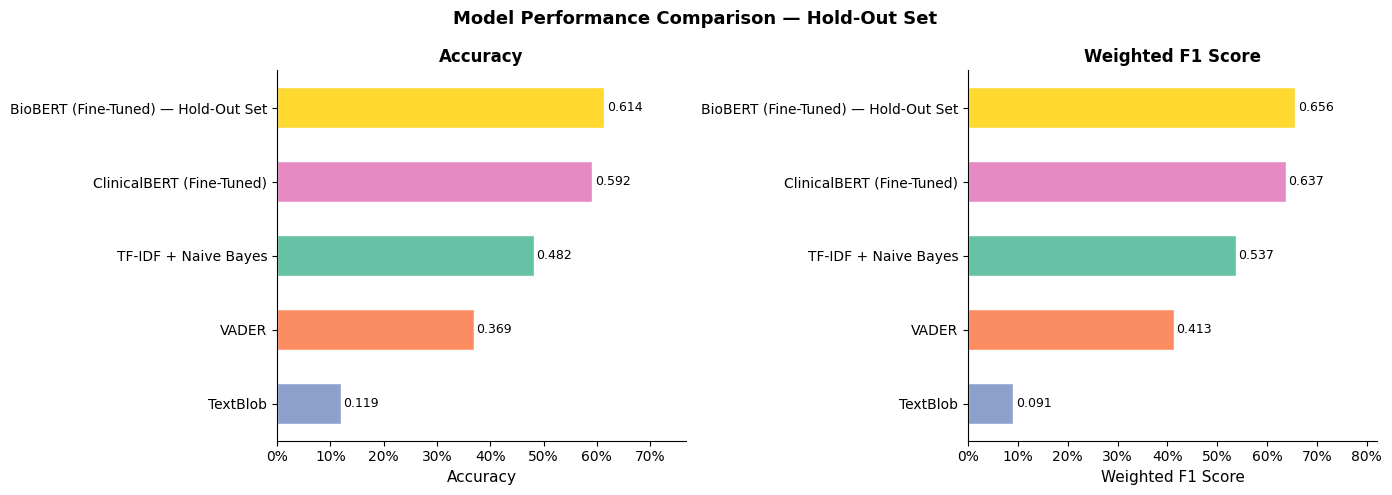

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance Comparison — Hold-Out Set", fontsize=13, fontweight="bold")

plot_df = pd.DataFrame(holdout_results)[["model", "accuracy", "weighted_f1"]]
plot_df = plot_df.sort_values("weighted_f1")
# Added a 5th color (gold) for ClinicalBERT
colors  = ["#8DA0CB", "#FC8D62", "#66C2A5", "#E78AC3", "#FFD92F"] 

for ax, metric, title in zip(axes, ["accuracy", "weighted_f1"], ["Accuracy", "Weighted F1 Score"]):
    bars = ax.barh(plot_df["model"], plot_df[metric], color=colors, edgecolor="white", height=0.55)
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.set_xlim(0, max(plot_df[metric]) * 1.25)
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


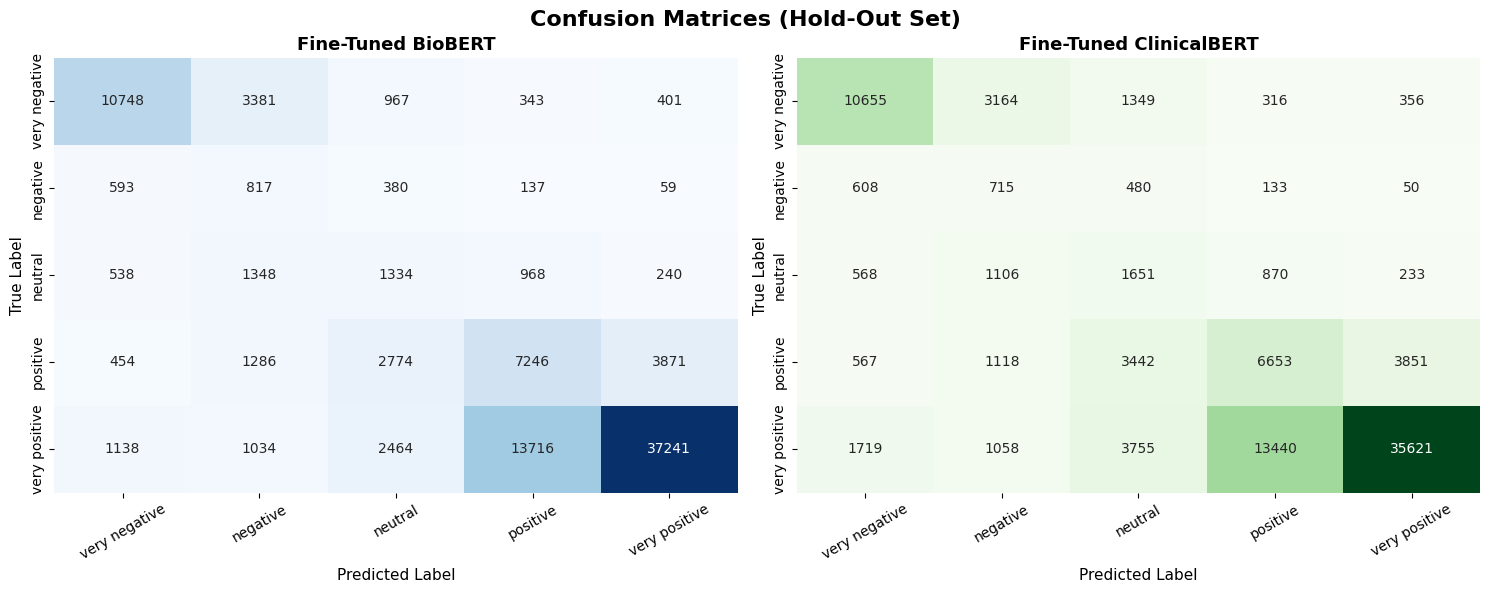

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# BioBERT Confusion Matrix
cm_bio = confusion_matrix(extra_df["sentiment"], extra_df["biobert_ft_pred"], labels=RATING_LABELS)
sns.heatmap(
    cm_bio, annot=True, fmt="d", cmap="Blues",
    xticklabels=RATING_LABELS, yticklabels=RATING_LABELS, ax=axes[0], cbar=False
)
axes[0].set_title("Fine-Tuned BioBERT", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# ClinicalBERT Confusion Matrix
cm_clin = confusion_matrix(extra_df["sentiment"], extra_df["clinbert_ft_pred"], labels=RATING_LABELS)
sns.heatmap(
    cm_clin, annot=True, fmt="d", cmap="Greens", 
    xticklabels=RATING_LABELS, yticklabels=RATING_LABELS, ax=axes[1], cbar=False
)
axes[1].set_title("Fine-Tuned ClinicalBERT", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle("Confusion Matrices (Hold-Out Set)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.90) 
plt.savefig("/kaggle/working/confusion_matrices_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


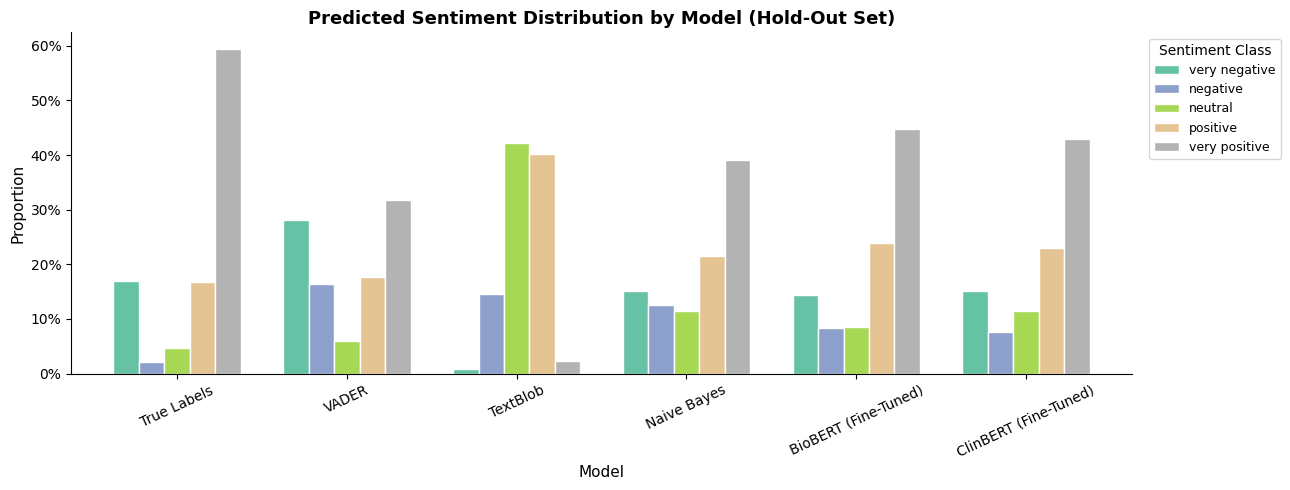

In [28]:
pred_cols = {
    "True Labels":          extra_df["sentiment"],
    "VADER":                extra_df["vader_pred"],
    "TextBlob":             extra_df["textblob_pred"],
    "Naive Bayes":          extra_df["mnb_pred"],
    "BioBERT (Fine-Tuned)": extra_df["biobert_ft_pred"],
    "ClinBERT (Fine-Tuned)": extra_df["clinbert_ft_pred"], 
}

dist_df = pd.DataFrame({
    name: series.value_counts(normalize=True).reindex(RATING_LABELS, fill_value=0)
    for name, series in pred_cols.items()
})

fig, ax = plt.subplots(figsize=(13, 5))
dist_df.T.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.75)
ax.set_title("Predicted Sentiment Distribution by Model (Hold-Out Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Proportion", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Sentiment Class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/prediction_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 13. Save Predictions and Metrics

We save all predictions and numeric metrics to the Kaggle working directory.



In [29]:
extra_df.to_csv("/kaggle/working/holdout_predictions.csv", index=False)
print("Saved: /kaggle/working/holdout_predictions.csv")

metrics_out = [
    {
        "model":       r["model"],
        "accuracy":    round(r["accuracy"],    4),
        "weighted_f1": round(r["weighted_f1"], 4),
    }
    for r in holdout_results
]

with open("/kaggle/working/metrics_summary.json", "w") as fh:
    json.dump(metrics_out, fh, indent=2)
print("Saved: /kaggle/working/metrics_summary.json")
print(json.dumps(metrics_out, indent=2))


Saved: /kaggle/working/holdout_predictions.csv
Saved: /kaggle/working/metrics_summary.json

[
  {
    "model": "VADER",
    "accuracy": 0.3687,
    "weighted_f1": 0.4133
  },
  {
    "model": "TextBlob",
    "accuracy": 0.1193,
    "weighted_f1": 0.0909
  },
  {
    "model": "TF-IDF + Naive Bayes",
    "accuracy": 0.4818,
    "weighted_f1": 0.5367
  },
  {
    "model": "BioBERT (Fine-Tuned) \u2014 Hold-Out Set",
    "accuracy": 0.6139,
    "weighted_f1": 0.6565
  },
  {
    "model": "ClinicalBERT (Fine-Tuned)",
    "accuracy": 0.5915,
    "weighted_f1": 0.637
  }
]


## 14. Discussion and Key Findings

1. General-purpose sentiment tools like VADER and TextBlob performed exceptionally poorly on this dataset (TextBlob achieved an F1 of 0.09). These models rely on predefined dictionaries where clinical terms (e.g., "disease," "pain," "surgery") often carry inherently negative weights. Consequently, when a patient writes a highly positive review like, "This medication completely relieved my severe pain," lexicon models misclassify it as negative due to the presence of the words "severe" and "pain." 

2. Both BioBERT (F1: 0.65) and ClinicalBERT (F1: 0.63) significantly outperformed traditional ML and Lexicon baselines. Their deep bidirectional attention mechanisms allow them to track complex negations (e.g., "did not help with the nausea at all") across long, unstructured sequences, heavily mitigating the false negatives seen in earlier models.

3. BioBERT vs. ClinicalBERT: 
Our core hypothesis was that ClinicalBERT, which was further pre-trained on MIMIC-III (messy, informal clinical notes), would outperform BioBERT (pre-trained on formal PubMed academic papers) because patient forum reviews are highly informal. 

    Interestingly, the empirical results showed the opposite: **BioBERT outperformed ClinicalBERT by ~2% in F1-score.** This suggests that the massive scale, diverse linguistic structure, and broader vocabulary of the PubMed corpus provided a more robust foundation for language understanding than the stylistic alignment of the MIMIC-III doctor's notes.

---
## 15. Limitations
- **Label Mapping Subjectivity**: Converting a 10-point numerical rating scale into 5 discrete sentiment classes is inherently subjective. For example, a rating of "6" might be considered "neutral" by one patient but "negative" by another, which introduces noise into the ground truth labels.
  
- **Context Length Truncation**: To fit within the constraints of GPU memory and execution time, reviews were truncated to 256 tokens. Exceptionally long patient stories may have had critical sentiment-bearing sentences truncated at the end of the text.
  
- **Data Imbalance Escaping**: While we perfectly balanced the training data, the real-world holdout set retains its natural extreme skew towards positive reviews, which heavily influences the class-wise accuracy.

---
## 16. Future Work
- **Explainable AI (XAI)**: Integrating frameworks like SHAP or LIME to visualize exactly which tokens (e.g., specific side effects or drug names) drive the transformer's sentiment predictions.
  
- **Ordinal Regression**: Redesigning the classification head to perform ordinal regression rather than independent categorical classification. In the current setup, predicting a 1 when the true label is a 2 is penalized the same as predicting a 1 when the true label is a 5. Ordinal regression would penalize extreme misses more heavily.
- **Data Augmentation**: Using back-translation or synthetic generation (via LLMs) to vastly expand the minority classes (neutral/negative) without relying on simple random oversampling.
